# 1. Importación de Librerías

In [11]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn import metrics
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
Cfrom xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, make_scorer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Dropout

# 2. Análisis Exploratorio de Datos

In [13]:
data = pd.read_csv('GOLD_2005_2025.csv')
data.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,08/26/2024,"2,520.20","2,512.60","2,527.70","2,509.30",0.66K,0.36%
1,08/23/2024,"2,511.20","2,486.20","2,518.70","2,486.10",0.75K,1.17%
2,08/22/2024,"2,482.10","2,515.60","2,516.00","2,472.60",0.74K,-1.22%
3,08/21/2024,"2,512.80","2,517.40","2,522.00","2,495.00",0.60K,-0.13%
4,08/20/2024,"2,516.10","2,507.70","2,535.40","2,502.10",0.66K,0.37%


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      5000 non-null   object
 1   Price     5000 non-null   object
 2   Open      5000 non-null   object
 3   High      5000 non-null   object
 4   Low       5000 non-null   object
 5   Vol.      4997 non-null   object
 6   Change %  5000 non-null   object
dtypes: object(7)
memory usage: 273.6+ KB


In [17]:
df = data.copy()

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [19]:
df.sort_index(inplace=True)
df.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2005-01-03,429.70,438.90,438.90,427.80,82.85K,-1.98%
2005-01-04,429.20,430.40,431.30,424.80,54.83K,-0.12%
2005-01-05,427.30,429.00,429.30,425.90,43.72K,-0.44%
2005-01-06,421.60,427.00,428.30,421.10,65.18K,-1.33%
2005-01-07,419.50,422.10,425.80,417.20,97.97K,-0.50%


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5000 entries, 2005-01-03 to 2024-08-26
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Price     5000 non-null   object
 1   Open      5000 non-null   object
 2   High      5000 non-null   object
 3   Low       5000 non-null   object
 4   Vol.      4997 non-null   object
 5   Change %  5000 non-null   object
dtypes: object(6)
memory usage: 273.4+ KB


In [23]:
# 1. Convertir columna 'Change %' a float (quitar % y dividir por 100)
df['Change %'] = df['Change %'].astype(str).str.replace('%', '').str.strip()
df['Change %'] = pd.to_numeric(df['Change %'], errors='coerce') / 100

# 2. Convertir columna 'Vol.' a float
def convertir_volumen(valor):
    if isinstance(valor, str):
        valor = valor.strip()
        if valor.endswith('K'):
            return float(valor.rstrip('K').replace(',', '')) * 1_000
        elif valor.endswith('M'):
            return float(valor.rstrip('M').replace(',', '')) * 1_000_000
    try:
        return float(valor)
    except:
        return np.nan

df['Vol.'] = df['Vol.'].apply(convertir_volumen)

# 3. Convertir las demás columnas numéricas directamente a float
columnas_numericas = ['Price', 'Open', 'High', 'Low']
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col].str.replace(',', ''), errors='coerce')

# Verificación
print(df.dtypes)
print(df.head())


Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %    float64
dtype: object
            Price   Open   High    Low     Vol.  Change %
Date                                                     
2005-01-03  429.7  438.9  438.9  427.8  82850.0   -0.0198
2005-01-04  429.2  430.4  431.3  424.8  54830.0   -0.0012
2005-01-05  427.3  429.0  429.3  425.9  43720.0   -0.0044
2005-01-06  421.6  427.0  428.3  421.1  65180.0   -0.0133
2005-01-07  419.5  422.1  425.8  417.2  97970.0   -0.0050


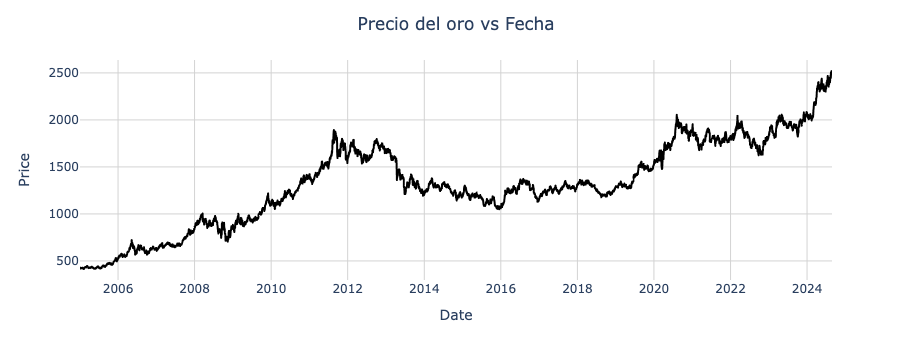

In [27]:
# Tendencia de los precios del oro respecto a la fecha correspondiente
fig = px.line(y=df.Price, x=df.index)

fig.update_traces(line_color='black') 

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Price",
    title={'text': "Precio del oro vs Fecha ", 'y':0.95, 'x':0.5, 'xanchor':'center', 'yanchor':'top'},
    plot_bgcolor='white',
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        hoverformat='%d-%m-%Y'  # PAra mostrar fecha exacta sobre cada punto
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray'
    )
)

fig.show()

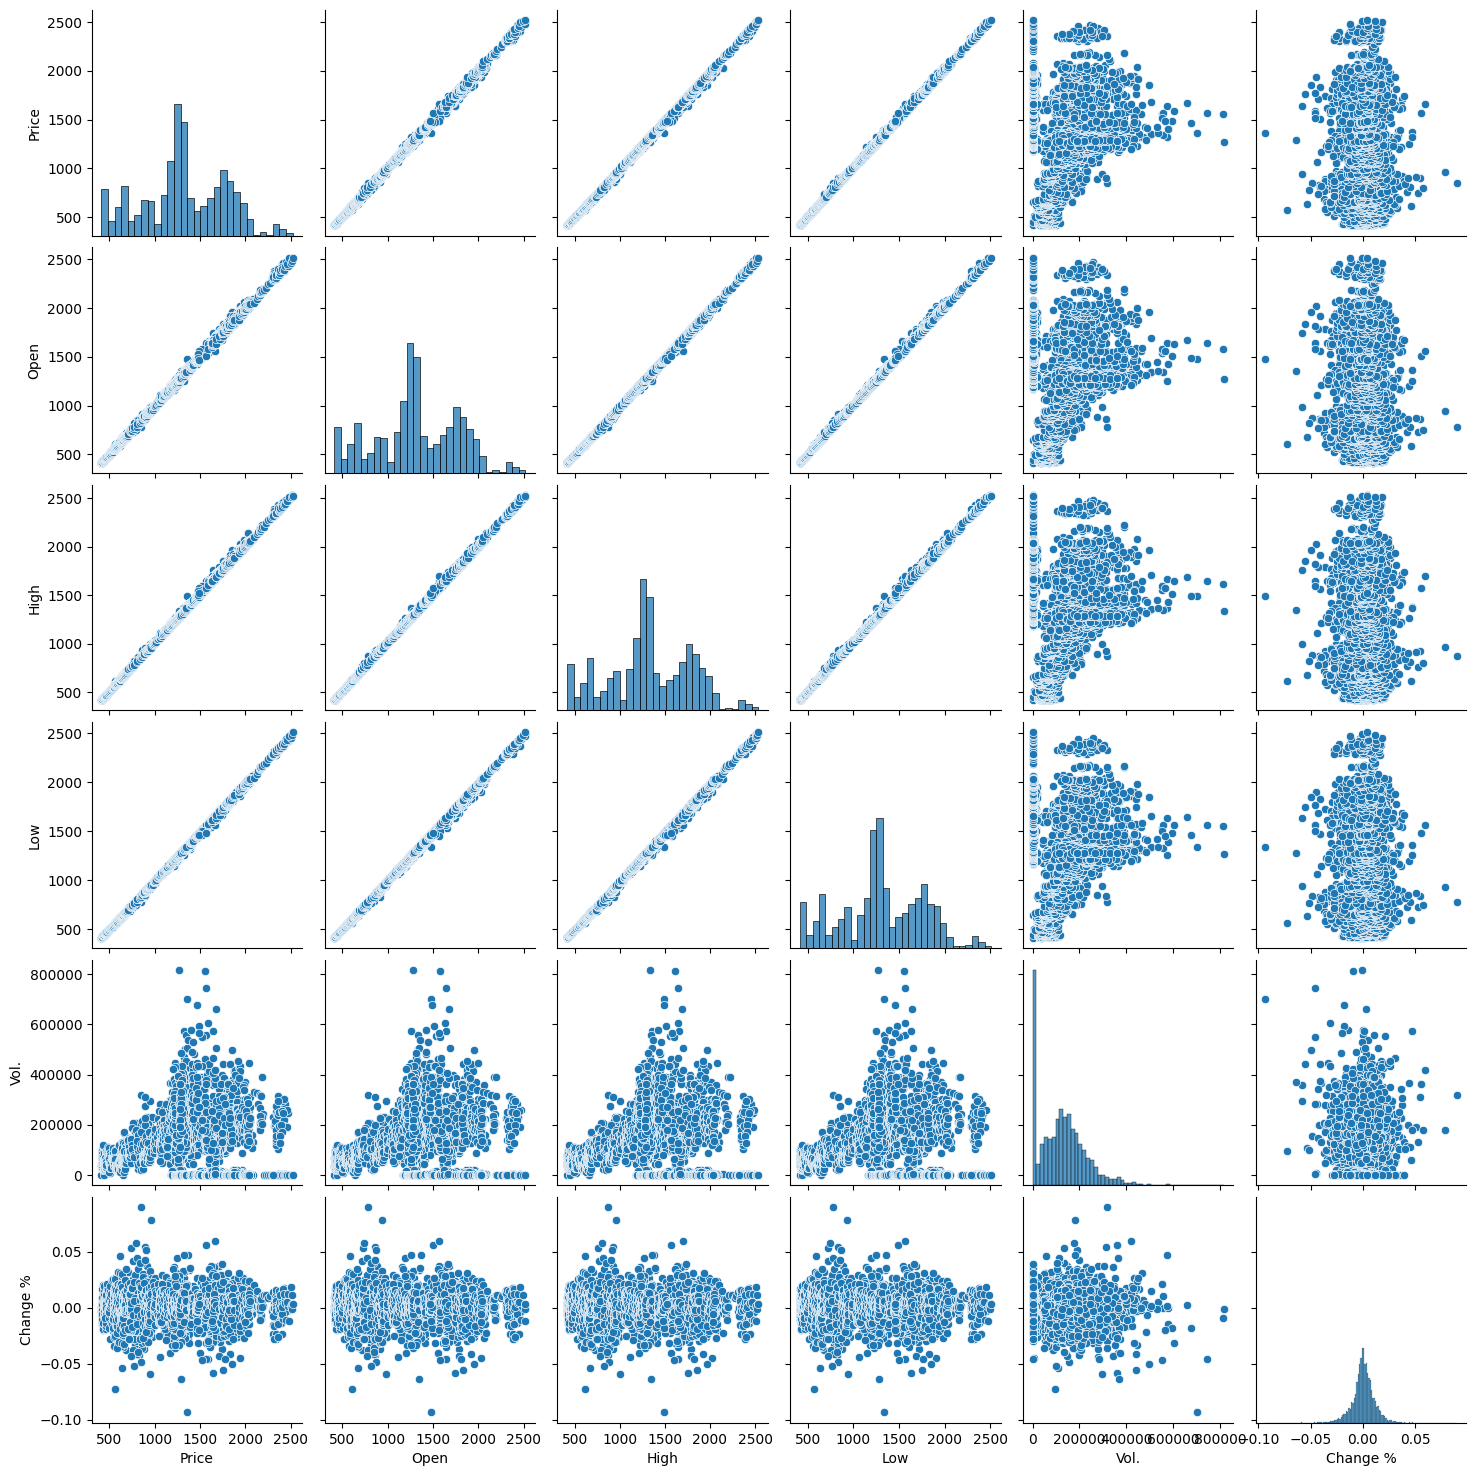

In [8]:
sns.pairplot(df)

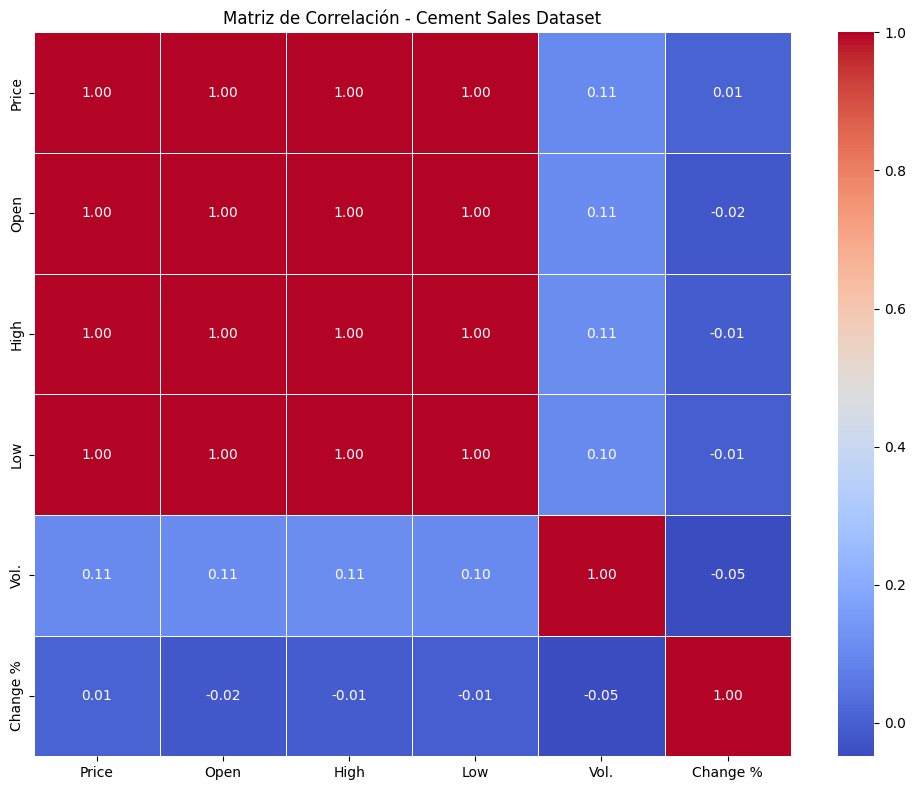

In [9]:
# Solo variables numéricas
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación - Cement Sales Dataset')
plt.tight_layout()
plt.show()

In [10]:
columnas_eliminar = ['Open', 'High', 'Low']
df.drop(columns=columnas_eliminar, inplace=True)

In [11]:
df.columns

Index(['Price', 'Vol.', 'Change %'], dtype='object')

In [12]:
df.dropna(inplace=True)

In [13]:
df.describe()

,Price,Vol.,Change %
count,4997.000000,4997.000000,4997.000000
mean,1319.793236,125572.651591,0.000414
std,451.662910,102185.714889,0.011116
min,414.300000,0.000000,-0.093400
25%,1075.200000,42590.000000,-0.004700
50%,1292.000000,120510.000000,0.000400
75%,1697.000000,183330.000000,0.006100
max,2520.200000,816530.000000,0.089700


In [14]:
data_por_año = df.resample('Y').size()

C:\Users\lfsoto\AppData\Local\Temp\ipykernel_20956\1315286602.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  data_por_año = df.resample('Y').size()


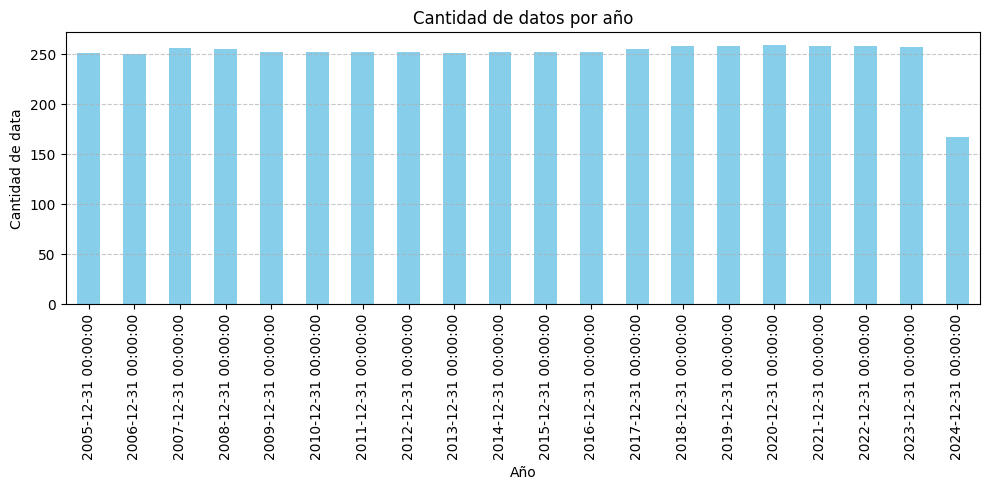

In [15]:
# 2. Graficar
plt.figure(figsize=(10, 5))
data_por_año.plot(kind='bar', color='skyblue')
plt.title('Cantidad de datos por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de data')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Análisis General

Se realizaron dos visualizaciones para explorar las relaciones entre las variables del dataset:

1. Pairplot
El pairplot muestra una fuerte relación lineal entre las variables Price, Open, High y Low, lo que sugiere una alta redundancia entre ellas.
La variable Volume presenta una gran dispersión y no muestra una relación clara con Price.
Change % tampoco presenta una relación aparente con el precio ni con las demás variables.

2. Matriz de Correlación
Las variables Price, Open, High y Low están altamente correlacionadas (coeficiente de 1.00), lo que indica que aportan información muy similar al modelo.
Volume tiene una correlación baja (0.10–0.11) con el precio, y Change % prácticamente no tiene correlación con ninguna variable (-0.05 a 0.01).

### Conclusión para el modelo
De acuerdo a lo observado en las dos gráficas, se eliminaron las variables con alta correlacion ya que no aportan información nueva respecto a la variable objetivo 'Price'. 

# 3. Random Forest

In [16]:
#Separamos entradas (X) y salidas (y)
X = df.drop(columns=['Price'], axis=1)
y = df['Price']

# 2. Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
# 3. Escalamos las numéricas
cols_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train[cols_to_scale])
X_test_sc = scaler.transform(X_test[cols_to_scale])

print(X_train_sc.shape, X_test_sc.shape, y_train.shape, y_test.shape)

(3497, 2) (1500, 2) (3497,) (1500,)


In [18]:
#Instancia del regresor
RF = RandomForestRegressor(n_estimators=100,max_depth=10)

#Entrenamos
RF.fit(X_train_sc,y_train)

#Predecimos
y_pred_rf=RF.predict(X_test_sc)

In [19]:
print('MAE:', metrics.mean_absolute_error(y_test, y_pred_rf))
print('MSE:', metrics.mean_squared_error(y_test, y_pred_rf))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf)))
print('R2_score:', metrics.r2_score(y_test, y_pred_rf))

MAE: 240.71569607350276
MSE: 90803.05244352146
RMSE: 301.335448368627
R2_score: 0.5662126312530504


In [20]:
importancias = pd.Series(RF.feature_importances_, index=X.columns)

# Ordenarlas de mayor a menor
importancias = importancias.sort_values(ascending=False)

print(importancias)


Vol.        0.839527
Change %    0.160473
dtype: float64


## Optimización de Hiperparametros

In [22]:
param_grid = {
    'n_estimators': np.arange(100,1010,100),              # Número de árboles
    'max_depth': np.arange(1,101,10),                 # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10],                        # Mínimo de muestras para dividir un nodo interno
    'min_samples_leaf': [1, 2, 4],                          # Mínimo de muestras por hoja
    'max_features': [None, 'sqrt', 'log2'],              # Número de features para buscar la mejor división
    'criterion': ['squared_error', 'absolute_error']       # Función de pérdida
}

#Defimos el modelo base

RF_gridSearch = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=100,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1
)

RF_gridSearch.fit(X_train,y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'criterion': ['squared_error', 'absolute_error'], 'max_depth': array([ 1, 11..., 71, 81, 91]), 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,100
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [23]:
#Revisamos los parametros seleccionados
RF_gridSearch.best_params_

{'n_estimators': np.int64(1000),
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': np.int64(11),
 'criterion': 'absolute_error'}

In [24]:
#Evaluamos el desempeño
y_pred = RF_gridSearch.best_estimator_.predict(X_test)
print("MAE: ", metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ", metrics.mean_squared_error(y_test,y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2:  ", metrics.r2_score(y_test,y_pred))

MAE:  232.20228243333335
MSE:  92822.04652744798
RMSE: 304.66710772160485
R2:   0.5565674254189525


# 4. XG Boost

In [25]:
# Instancia del modelo
xgb_model = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.02,
    random_state=42
)

# Entrenar el modelo
xgb_model.fit(X_train_sc, y_train)

# Predecir
y_pred_xgb = xgb_model.predict(X_test_sc)

# Evaluar
print('MAE:', metrics.mean_absolute_error(y_test, y_pred_xgb))
print('MSE:', metrics.mean_squared_error(y_test, y_pred_xgb))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_xgb)))
print('R2_score:', metrics.r2_score(y_test, y_pred_xgb))


MAE: 240.9102577718099
MSE: 99570.89790719203
RMSE: 315.54856663783477
R2_score: 0.5243265876574212


## Optimización de Hiperparámetros

In [ ]:
xgb = XGBRegressor(objective='reg:absoluteerror', random_state=42)

param_grid = {
    'n_estimators': np.arange(100, 600, 100),
    'max_depth': [3, 5, 7, 10],
    'learning_rate': np.linspace(0.001, 0.3, 10),
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

In [27]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    cv=3,
    scoring=make_scorer(mean_absolute_error, greater_is_better=False),
    verbose=1,
    n_jobs=-1  # Usa todos los núcleos disponibles
)

In [28]:
random_search.fit(X_train_sc, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 1, ...], 'learning_rate': array([0.001 ..., 0.3 ]), 'max_depth': [3, 5, ...], ...}"
,n_iter,10
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [29]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test_sc)

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R²:', metrics.r2_score(y_test, y_pred))

MAE: 233.13444552408853
RMSE: 312.41020963340003
R²: 0.5337413624000721


# 5. División de los datos para RNN y LSTM

In [33]:
# Leer datos 
data = df[['Price']]

# Escalamos
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Creamos ventanas de tiempo
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

window_size = 12  # 12 meses anteriores
X, y = create_sequences(data_scaled, window_size)

# Dividimos en entrenamiento y prueba
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [34]:
print(X_train.shape)

(3988, 12, 1)


## *Visualización datos de entrenamiento*

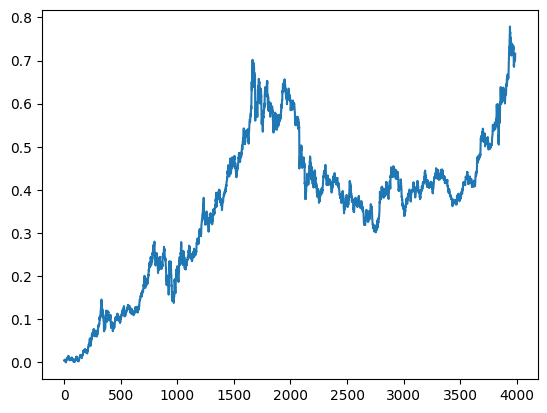

In [35]:
#Datos de entrenamiento
X_train_2D = X_train[:, -1, :]
plt.plot(X_train_2D)

## *Visualización datos de prueba*

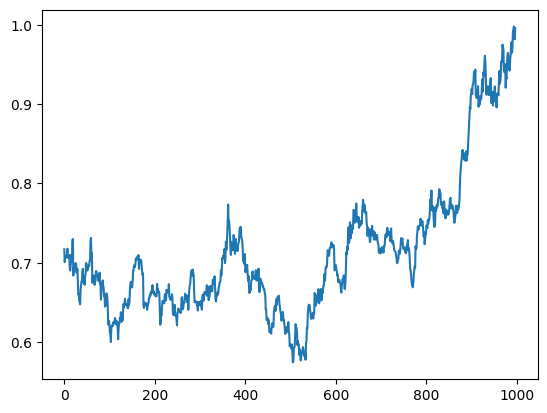

In [36]:
#Datos de prueba
X_test_2D = X_test[:, -1, :]
plt.plot(X_test_2D)

## 5.1. RNN

In [42]:
# Definción de la red
model = Sequential()
model.add(SimpleRNN(128, activation="tanh", input_shape=(window_size,1), return_sequences=True))
model.add(SimpleRNN(64, activation="tanh", return_sequences=True))
model.add(SimpleRNN(28, activation="tanh", return_sequences=False))
model.add(Dense(1))

#Compilación del modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenamiento
model.fit(X_train, y_train, epochs=50, verbose=1)

Epoch 1/50


c:\Users\lfsoto\Github\Producto de datos\cement_sales\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0492
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.2525e-04
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.3223e-04
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.6802e-04
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0849e-04
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0203e-04
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8921e-04
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8134e-04
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0658e-04
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1526e-04
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9330e-04
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4386e-04
Epoch 13/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6445e-04
Epoch 14/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.3218e-04
Epoch 15/50
125/

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE:  1288.9342469385888
RMSE:  35.90173041705077
MAE:  23.720479651846166
R2_score:  0.9635803857721628


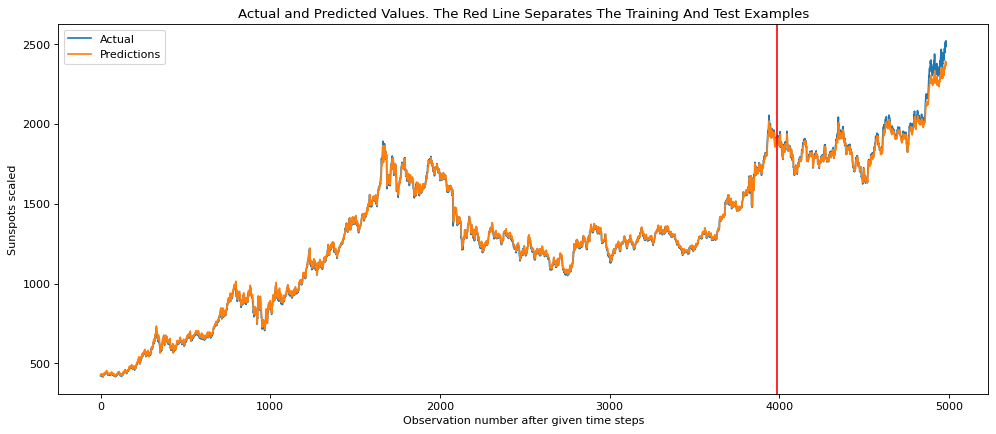

In [43]:
# Predicciones
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train) #Sobre datos de entrenamiento

# Inversión del escalado
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_train_pred_inv = scaler.inverse_transform(y_train_pred)
y_train_inv = scaler.inverse_transform(y_train)

# Métricas
print('MSE: ', metrics.mean_squared_error(y_test_inv,y_pred_inv))
print('RMSE: ', np.sqrt(metrics.mean_squared_error(y_test_inv,y_pred_inv)))
print('MAE: ', metrics.mean_absolute_error(y_test_inv,y_pred_inv))
print('R2_score: ', metrics.r2_score(y_test_inv,y_pred_inv))

# Visualización de los resultados
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
plot_result(y_train_inv, y_test_inv, y_train_pred_inv, y_pred_inv)

## 5.2. LSTM

In [44]:
# Definción de la red
model_LSTM = Sequential()
model_LSTM.add(LSTM(128, activation='relu', input_shape=(X_train.shape[1], 1), return_sequences=True))
model_LSTM.add(LSTM(64, activation="tanh", return_sequences=True))
model_LSTM.add(LSTM(28, activation="tanh", return_sequences=False))
model_LSTM.add(Dense(1))

#Compilación del model_LSTMo
model_LSTM.compile(optimizer='adam', loss='mean_squared_error')

# Entrenamiento
model_LSTM.fit(X_train, y_train, epochs=50, verbose=1)

Epoch 1/50


c:\Users\lfsoto\Github\Producto de datos\cement_sales\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0261
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5651e-04
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7831e-04
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6550e-04
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.6969e-04
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2.4350e-04
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.4755e-04
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 3.2264e-04
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2.3464e-04
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.1866e-04
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.2582e-04
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 2.5860e-04
Epoch 13/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2.1559e-04
Epoch 14/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 1.8539e-04
Ep

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MSE:  471.30881374483914
RMSE:  21.709647941522203
MAE:  16.91533719811779
R2_score:  0.9866828853220901


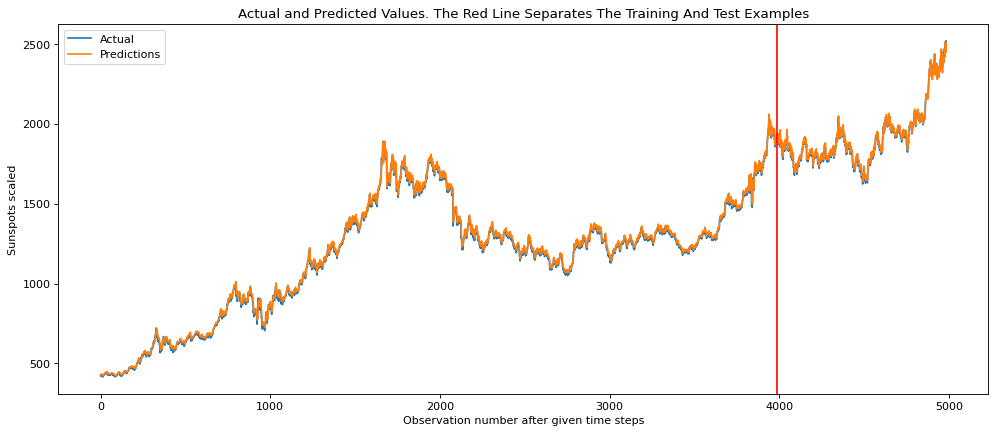

In [45]:
# Predicciones
y_pred = model_LSTM.predict(X_test)
y_train_pred = model_LSTM.predict(X_train) 

# Inversión del escalado
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_train_pred_inv = scaler.inverse_transform(y_train_pred)
y_train_inv = scaler.inverse_transform(y_train)

# Métricas
print('MSE: ', metrics.mean_squared_error(y_test_inv,y_pred_inv))
print('RMSE: ', np.sqrt(metrics.mean_squared_error(y_test_inv,y_pred_inv)))
print('MAE: ', metrics.mean_absolute_error(y_test_inv,y_pred_inv))
print('R2_score: ', metrics.r2_score(y_test_inv,y_pred_inv))

# Visualización de los resultados
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
plot_result(y_train_inv, y_test_inv, y_train_pred_inv, y_pred_inv)